# Laboratorio 3 Deep Learning: Reconocimiento de Lenguaje de Señas (ASL)

SignBridge, una startup guatemalteca de tecnología inclusiva, nos contrató para construir el primer prototipo de un motor de reconocimiento de letras del alfabeto de Lenguaje de Señas Americano (ASL) a partir de imágenes de manos.

## 0. Configuración e imports

In [1]:
import os
import json
import random
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

C:\Users\gabri\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Descarga del dataset

Usamos `kagglehub` para descargar el dataset [ASL Alphabet](https://www.kaggle.com/datasets/grassknoted/asl-alphabet). `kagglehub` cachea el dataset localmente (fuera del repositorio, típicamente en `~/.cache/kagglehub`) y solo vuelve a descargarlo si no existe, por lo que es seguro volver a correr esta celda. El dataset **no se sube al repositorio** (ver `.gitignore`); cualquier persona que clone el repo simplemente vuelve a correr esta celda para obtenerlo.

In [2]:
# Download latest version
path = kagglehub.dataset_download("grassknoted/asl-alphabet")

print("Path to dataset files:", path)

DATASET_DIR = Path(path)
TRAIN_DIR = DATASET_DIR / "asl_alphabet_train" / "asl_alphabet_train"
TEST_DIR = DATASET_DIR / "asl_alphabet_test" / "asl_alphabet_test"

assert TRAIN_DIR.exists(), f"No se encontró la carpeta de entrenamiento en {TRAIN_DIR}"
assert TEST_DIR.exists(), f"No se encontró la carpeta de prueba oficial en {TEST_DIR}"

CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print(f"Número de clases: {len(CLASSES)}")
print(CLASSES)

Path to dataset files: C:\Users\gabri\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1
Número de clases: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 2. Estructura general del dataset

Contamos cuántas imágenes hay por clase dentro de la carpeta de entrenamiento y revisamos qué tan grande es el set de prueba oficial de Kaggle.

In [3]:
counts = {c: len(list((TRAIN_DIR / c).glob("*.jpg"))) for c in CLASSES}
df_counts = pd.DataFrame({"clase": list(counts.keys()), "n_imagenes": list(counts.values())})
df_counts = df_counts.sort_values("clase").reset_index(drop=True)

test_files = list(TEST_DIR.glob("*.jpg"))

print(f"Total de imágenes de entrenamiento disponibles: {df_counts['n_imagenes'].sum()}")
print(f"Número de clases: {df_counts.shape[0]}")
print(f"Imágenes en el set de prueba OFICIAL de Kaggle: {len(test_files)}")
df_counts

Total de imágenes de entrenamiento disponibles: 87000
Número de clases: 29
Imágenes en el set de prueba OFICIAL de Kaggle: 28


,clase,n_imagenes
0,A,3000
1,B,3000
2,C,3000
3,D,3000
4,E,3000
5,F,3000
6,G,3000
7,H,3000
8,I,3000
9,J,3000


**Hallazgo:** el dataset trae 29 clases (A-Z, `space`, `del`, `nothing`) con ~3,000 imágenes cada una (~87,000 en total), es decir, está **perfectamente balanceado por clase**. El set de prueba oficial de Kaggle trae apenas ~28 imágenes (una por letra), a propósito, para forzar a construir nuestro propio conjunto de entrenamiento/validación/prueba a partir de las ~87,000 imágenes de entrenamiento (ver sección 2.4 del EDA).

## Ejercicio 1: Ejemplos de letras y variabilidad intra-clase

Mostramos varias muestras de distintas letras, incluyendo tanto letras "fáciles" como letras que visualmente podrían confundirse entre sí, para observar la variabilidad dentro de una misma clase (rotación de la mano, encuadre, iluminación, etc.).

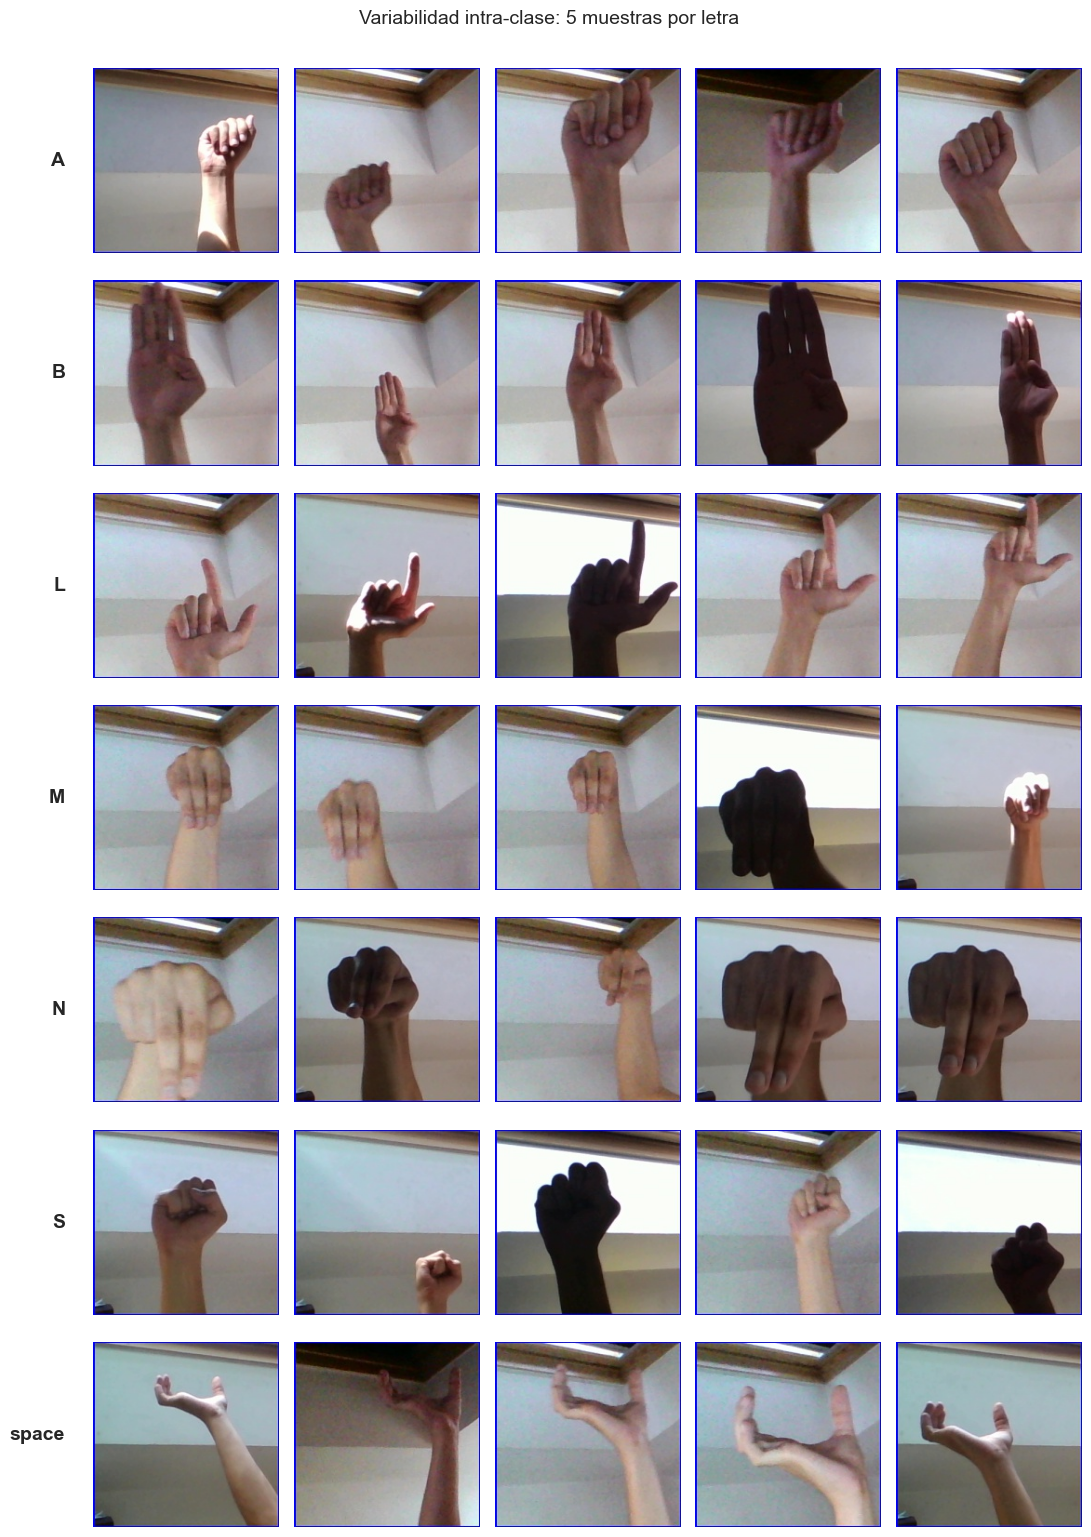

In [4]:
def show_class_samples(classes, n_samples=5, seed=SEED):
    rng = random.Random(seed)
    fig, axes = plt.subplots(len(classes), n_samples, figsize=(2.2 * n_samples, 2.2 * len(classes)))
    for i, c in enumerate(classes):
        files = list((TRAIN_DIR / c).glob("*.jpg"))
        sample_files = rng.sample(files, n_samples)
        for j, f in enumerate(sample_files):
            img = Image.open(f)
            ax = axes[i, j] if len(classes) > 1 else axes[j]
            ax.imshow(img)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(c, fontsize=12)
                ax.text(-0.15, 0.5, c, fontsize=14, fontweight="bold",
                        transform=ax.transAxes, va="center", ha="right")
    plt.suptitle("Variabilidad intra-clase: 5 muestras por letra", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

show_class_samples(["A", "B", "L", "M", "N", "S", "space"], n_samples=5)

**Hallazgo:** dentro de una misma clase la seña mantiene la misma configuración de dedos, pero varía ligeramente la rotación/inclinación de la mano, el encuadre respecto a la cámara y, en menor medida, la iluminación. El fondo es consistente entre imágenes de la misma sesión de captura, lo cual es importante para la reflexión de accesibilidad más adelante (sección de plan).